# **Ensemble Learning Voting Regression**

In [51]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings('ignore')

In [52]:
from sklearn.datasets import fetch_california_housing

cal_house_prices = fetch_california_housing()
df = pd.DataFrame(cal_house_prices.data, columns=cal_house_prices.feature_names)
df['prices'] = cal_house_prices.target

df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,prices
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
prices        0
dtype: int64



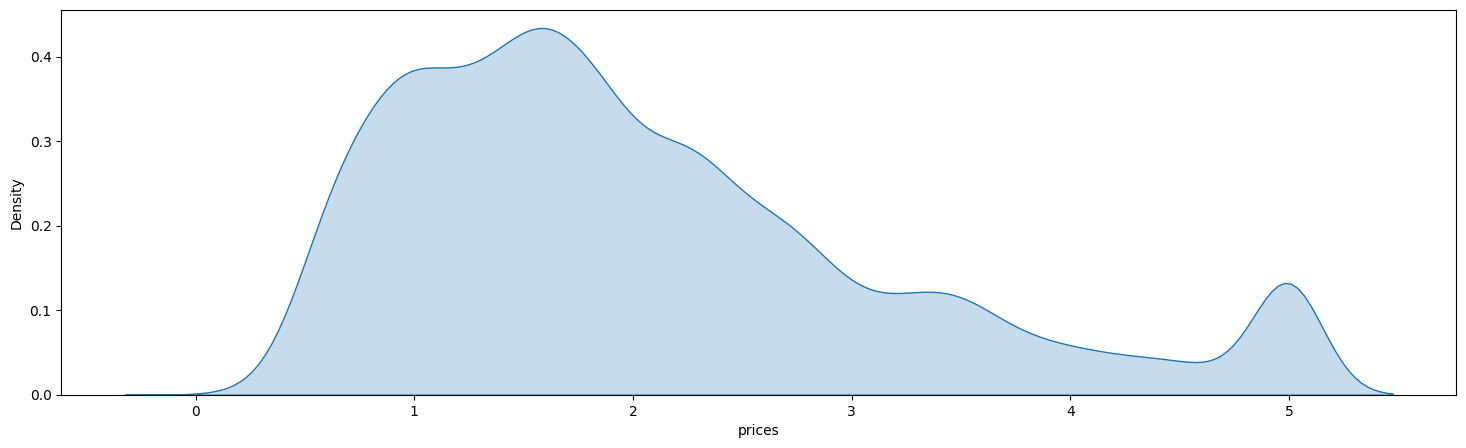

In [53]:
# doing feature selection

print(df.isna().sum())
print()


# checking if the data is normally distributed or not
plt.figure(figsize=(18, 5))
sns.kdeplot(df['prices'], fill=True)            # the data is not normally distributed*)
plt.show()

In [54]:
X = df.drop(columns='prices')
y = df['prices']


lr = LinearRegression()
# rf = RandomForestRegressor()
knn = KNeighborsRegressor()
# svr = SVR()
dt = DecisionTreeRegressor()

# we removed rf and svr coz it takes a hell lot of time to do the computations

# models = [('lr', lr), ('rf', dt), ('knn', knn), ('svr', svr)]
models = [('lr', lr), ('knn', knn), ('dt', dt)]

for i in models:
    ans = np.round(np.mean(cross_val_score(i[1], X, y, cv=10, scoring='r2')), 2)
    print(f"{i[0]} : {ans}")

lr : 0.51
knn : -0.14
dt : 0.25


In [57]:
vr = VotingRegressor(
    estimators = models
    # voting = 'hard'       # voting parameter will throw error in VotingRegressor
)

print(np.round(np.mean(cross_val_score(vr, X, y, cv=10, scoring='r2')), 2))

0.48
